# Simulating tibial SSEP data
This notebook defines a simple simulator for tibial SSEP data, which can be used to generate synthetic datasets for testing and benchmarking analysis pipelines. The simulator is designed to be flexible, allowing for different peak shapes, jitter, and noise levels. The core idea is to define a base `Peak` class that models a single SSEP component, and then create child classes that implement specific peak shapes (e.g., Gaussian with rebound, difference-of-exponentials). The main simulation function then combines these peaks with optional jitter and noise to produce realistic synthetic SSEP signals.




In the next cell, we define the base `Peak` class and two child classes: `GaussianReboundPeak` and `DiffExpPeak`. Each class has a `waveform` method that generates the time course of the peak given an array of time points. The main simulation function, `simulate_tibial_ssep_single_trial`, takes a list of peaks and simulates a single trial by summing their waveforms, adding jitter to the latency and amplitude, and optionally adding pink noise.

In [2]:
import numpy as np
from dataclasses import dataclass, field
# ----------------------------
# Base class
# ----------------------------
@dataclass
class Peak:
    name: str
    latency_ms: float
    amp_uv: float
    width_ms: float = 5.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        return self.amp_uv * np.exp(-0.5 * ((t_ms - self.latency_ms) / self.width_ms) ** 2)


# ----------------------------
# Child 1: Gaussian + rebound
# ----------------------------
@dataclass
class GaussianReboundPeak(Peak):
    width_ms: float = 4.0
    rebound_frac: float = 0.25
    rebound_delay_ms: float = 8.0
    rebound_width_ms: float = 6.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        main = self.amp_uv * np.exp(-0.5 * ((t_ms - self.latency_ms) / self.width_ms) ** 2)
        rebound = (-self.amp_uv * self.rebound_frac) * np.exp(
            -0.5 * ((t_ms - (self.latency_ms + self.rebound_delay_ms)) / self.rebound_width_ms) ** 2
        )
        return main + rebound


# ----------------------------
# Child 2: Difference-of-exponentials (peak time = latency_ms)
# ----------------------------
@dataclass
class DiffExpPeak(Peak):
    tau_rise_ms: float = 1.0
    tau_decay_ms: float = 8.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        tr, td = self.tau_rise_ms, self.tau_decay_ms
        if td <= tr:
            raise ValueError(f"{self.name}: tau_decay_ms must be > tau_rise_ms")

        dt = t_ms - self.latency_ms
        y = np.zeros_like(t_ms, dtype=float)

        m = dt >= 0
        d = dt[m]

        raw = np.exp(-d / td) - np.exp(-d / tr)

        d_star = (tr * td / (td - tr)) * np.log(td / tr)
        raw_max = np.exp(-d_star / td) - np.exp(-d_star / tr)

        y[m] = self.amp_uv * (raw / raw_max)
        return y

# ----------------------------
# Child 3: wavelet-shaped peak (Morlet wavelet with specified frequency, length where the center of the wavelet is at latency_ms
@dataclass
class WaveletPeak(Peak):
    freq_hz: float = 40.0
    n_cycles: float = 7.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        from scipy.signal import morlet2

        sf = self.freq_hz / self.n_cycles
        w = morlet2(M=len(t_ms), w=self.n_cycles, s=sf * (1000.0 / self.fs))
        # shift wavelet so its center is at latency_ms
        t_shifted = t_ms - self.latency_ms
        idx = np.argmin(np.abs(t_shifted))
        w_shifted = np.roll(w, idx - len(w) // 2)
        return self.amp_uv * w_shifted.real



# ----------------------------
# Simulator: now peak-agnostic
# ----------------------------
def simulate_tibial_ssep_single_trial(
        fs=5000,
        tmin_ms=-20.0,
        tmax_ms=120.0,
        peaks=None,
        latency_jitter_ms=0.6,
        amp_jitter_frac=0.10,
        noise_rms_uv=0.0,
        rng_seed=None,
        add_ringing=False,
):
    rng = np.random.default_rng(rng_seed)
    t_ms = np.arange(tmin_ms, tmax_ms, 1000.0 / fs)
    sig = np.zeros_like(t_ms, dtype=float)

    for p in peaks:
        # trial jitter: make a shallow copy with jittered params
        lat = p.latency_ms + rng.normal(0, latency_jitter_ms)
        amp = p.amp_uv * (1.0 + rng.normal(0, amp_jitter_frac))

        # copy object while preserving its class + extra fields
        p_trial = type(p)(**{**p.__dict__, "latency_ms": lat, "amp_uv": amp})
        sig += p_trial.waveform(t_ms)

    if noise_rms_uv > 0:
        sig += rng.normal(0, noise_rms_uv, size=len(t_ms))

    return t_ms, sig

In the following cell we will define some filtering functions that can be used to process the simulated data. These include a simple low-pass filter and a band-pass filter, which can be applied to the simulated SSEP signals to mimic typical preprocessing steps in real data analysis pipelines. The filters are implemented using Butterworth designs, and we will use the `scipy.signal` library for the actual filtering operations. Importantly, these filters are zero-phase (using `filtfilt`) to avoid introducing any phase distortion, which is crucial for preserving the temporal characteristics of the SSEP peaks.

In [3]:
# defining some simple filters for processing the simulated data
from scipy.signal import butter, filtfilt

def lowpass_filter(data, fs, cutoff_hz=200.0, order=4):
    b, a = butter(order, cutoff_hz / (0.5 * fs), btype="low")
    return filtfilt(b, a, data)

def bandpass_filter(data, fs, low_hz=1.0, high_hz=200.0, order=4):
    b, a = butter(order, [low_hz / (0.5 * fs), high_hz / (0.5 * fs)], btype="band")
    return filtfilt(b, a, data)



In the next cell we will define a class called preprocessor that can be used to apply a sequence of preprocessing steps to the simulated SSEP data. This class will allow us to easily apply multiple filters and other transformations in a consistent way. The `Preprocessor` class will have methods for adding filters to the processing pipeline, as well as a method for applying the entire pipeline to a given signal. This design allows for flexibility in how we preprocess the simulated data, and makes it easy to experiment with different combinations of filters and parameters.

In [4]:
from dataclasses import dataclass, asdict
from typing import Any

@dataclass
class ProcessingStep:
    name: str
    params: dict[str, Any]

class Preprocessor:
    def __init__(self, fs: int):
        self.fs = fs
        self.steps: list[ProcessingStep] = []

    def add_lowpass(self, cutoff_hz: float = 200.0, order: int = 4):
        self.steps.append(
            ProcessingStep("lowpass", {"cutoff_hz": cutoff_hz, "order": order})
        )

    def add_bandpass(self, low_hz: float = 1.0, high_hz: float = 200.0, order: int = 4):
        self.steps.append(
            ProcessingStep("bandpass", {"low_hz": low_hz, "high_hz": high_hz, "order": order})
        )

    def apply(self, data):
        for step in self.steps:
            data = self._apply_step(step, data)
        return data

    def _apply_step(self, step: ProcessingStep, data):
        if step.name == "lowpass":
            return lowpass_filter(data, self.fs, **step.params)
        if step.name == "bandpass":
            return bandpass_filter(data, self.fs, **step.params)
        raise ValueError(f"Unknown step: {step.name}")

    def describe(self):
        # JSON-friendly list of dicts
        return [asdict(s) for s in self.steps]

    @classmethod
    def from_description(cls, fs: int, steps_desc: list[dict[str, Any]]):
        """
        Rebuild a Preprocessor from something previously returned by describe().
        """
        p = cls(fs)
        for d in steps_desc:
            p.steps.append(ProcessingStep(name=d["name"], params=d["params"]))
        return p


#small sanity check to make sure the preprocessor can be created and applied without errors
prep = Preprocessor(fs=5000)
prep.add_bandpass(10, 200)
prep.add_lowpass(150, order=2)

print(prep.describe())
desc = prep.describe()
# save desc somewhere (JSON, file, inside Dataset, etc.)

prep2 = Preprocessor.from_description(fs=5000, steps_desc=desc)
print(prep2.describe())


[{'name': 'bandpass', 'params': {'low_hz': 10, 'high_hz': 200, 'order': 4}}, {'name': 'lowpass', 'params': {'cutoff_hz': 150, 'order': 2}}]
[{'name': 'bandpass', 'params': {'low_hz': 10, 'high_hz': 200, 'order': 4}}, {'name': 'lowpass', 'params': {'cutoff_hz': 150, 'order': 2}}]


The next block will define a class called `wavelet_family` that can be used to generate and manage a family of complex Morlet wavelets with variable FWHM (full width at half maximum). This class will allow us to create wavelets with specific frequencies and widths, and to compute their empirical FWHM in both the frequency and time domains. The class will also include methods for plotting the wavelets and their properties, which can be useful for visualizing the characteristics of the wavelet family and understanding how the parameters affect their shape and spectral properties.

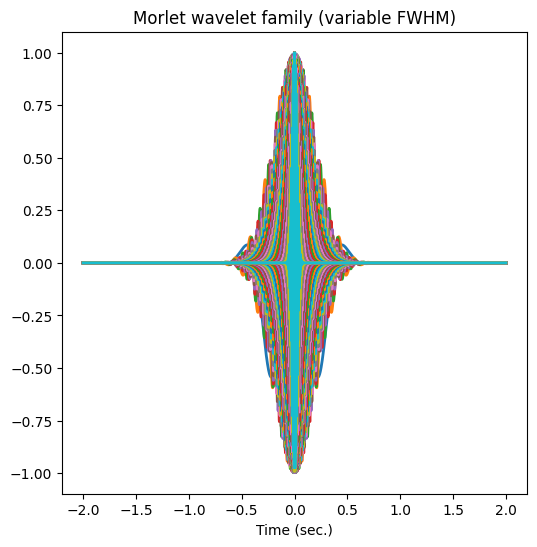

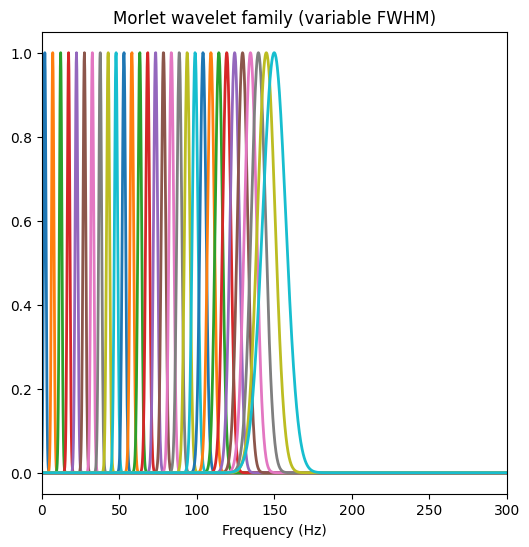

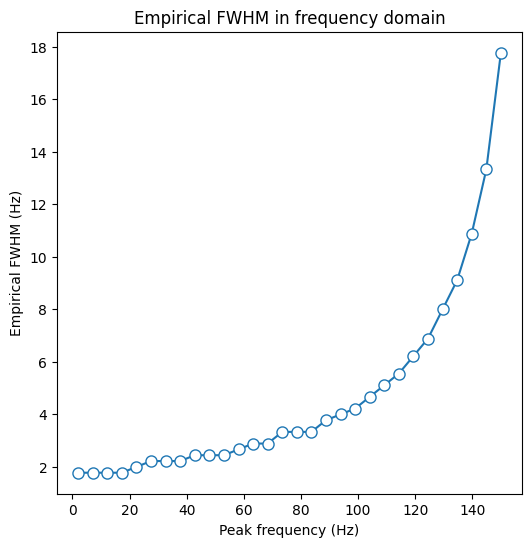

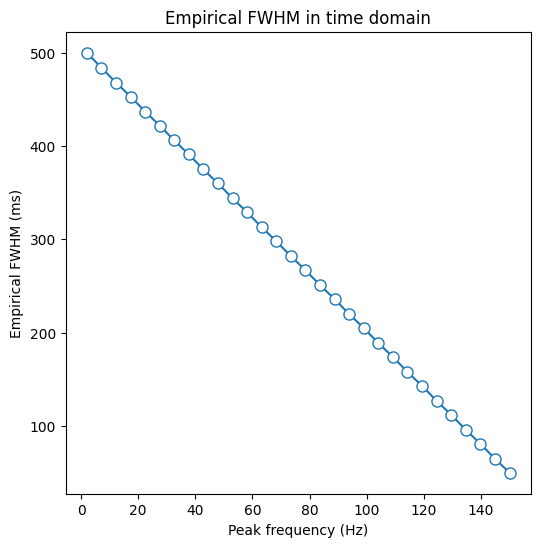

In [11]:
# here we are going to generate a class of data called wavelet family
import numpy as np
import matplotlib.pyplot as plt


class wavelet_family:
    """
    Build and manage a family of complex Morlet wavelets (variable FWHM).

    After calling build(), you get:
      - self.wavelets: list of complex wavelets in time domain
      - self.emp_fwhm_freq: empirical FWHM (Hz) for each wavelet
      - self.emp_fwhm_time: empirical FWHM (sec) for each wavelet
      - self.hz: frequency axis used for FFT-based measurements/plots
    """

    def __init__(self, frex, fwhm, srate, wavtime, n_data):
        self.frex = np.asarray(frex, dtype=float)
        self.fwhm = np.asarray(fwhm, dtype=float)
        self.srate = float(srate)
        self.wavtime = np.asarray(wavtime, dtype=float)
        self.n_data = int(n_data)

        self.n_conv = len(self.wavtime) + self.n_data - 1

        self.wavelets = None
        self.emp_fwhm_freq = None
        self.emp_fwhm_time = None
        self.hz = None
        self._waveX_cache = {}

        self._validate()

    def _validate(self):
        if self.frex.shape != self.fwhm.shape:
            raise ValueError("frex and fwhm must be the same length.")
        if np.any(self.fwhm <= 0):
            raise ValueError("All fwhm values must be > 0.")
        if np.max(self.frex) >= self.srate / 2:
            raise ValueError("Some frex exceed Nyquist (srate/2).")
        if self.n_data <= 0:
            raise ValueError("n_data must be a positive integer.")

    def build(self):
        """Create wavelets and compute empirical FWHM in freq + time."""
        n = len(self.frex)
        self.wavelets = []
        self.emp_fwhm_freq = np.zeros(n, dtype=float)
        self.emp_fwhm_time = np.zeros(n, dtype=float)
        self._waveX_cache = {}

        self.hz = np.arange(self.n_conv) * self.srate / self.n_conv

        for fi in range(n):
            # complex Morlet: complex sinusoid * Gaussian (parameterized by FWHM)
            w = (
                    np.exp(2 * 1j * np.pi * self.frex[fi] * self.wavtime)
                    * np.exp(-4 * np.log(2) * (self.wavtime**2) / (self.fwhm[fi] ** 2))
            )
            self.wavelets.append(w)

            # --- empirical FWHM in frequency domain ---
            waveX = np.fft.fft(w, n=self.n_conv)
            waveX = waveX / np.max(np.abs(waveX))  # normalize
            amp = np.abs(waveX)

            idx_peak = int(np.argmin(np.abs(self.hz - self.frex[fi])))

            # Find closest-to-half-max points on each side of peak
            # (mirrors your original approach, but uses magnitude explicitly)
            left_region = amp[: idx_peak + 1]
            right_region = amp[idx_peak:]

            left_idx = int(np.argmin(np.abs(left_region - 0.5)))
            right_idx = idx_peak + int(np.argmin(np.abs(right_region - 0.5)))

            self.emp_fwhm_freq[fi] = self.hz[right_idx] - self.hz[left_idx]

            # --- empirical FWHM in time domain ---
            env = np.abs(w)
            halfmax = env.max() / 2.0
            above = np.where(env >= halfmax)[0]
            if above.size < 2:
                self.emp_fwhm_time[fi] = np.nan
            else:
                self.emp_fwhm_time[fi] = self.wavtime[above[-1]] - self.wavtime[above[0]]

        return self  # allows chaining

    def get_waveX_list(self, nConv, normalize=True):
        """
        Return cached FFTs of all wavelets at a given convolution length nConv.

        Parameters
        ----------
        nConv : int
            FFT length for convolution (nWave + nData - 1).
        normalize : bool
            If True, normalize each waveX by its max abs value (Cohen style).

        Returns
        -------
        waveX_list : list of np.ndarray
            List of wavelet FFTs, one per frequency.
        """
        if self.wavelets is None:
            raise ValueError("Wavelets not built. Run wavelet_family.build() first.")

        key = (int(nConv), bool(normalize))

        if key in self._waveX_cache:
            return self._waveX_cache[key]

        waveX_list = []
        for w in self.wavelets:
            waveX = np.fft.fft(w, nConv)
            if normalize:
                waveX = waveX / np.max(np.abs(waveX))
            waveX_list.append(waveX)

        self._waveX_cache[key] = waveX_list
        return waveX_list




    # -------- plotting helpers --------
    def plot_time_family(self, real_part=True, figsize=(6, 6), linewidth=2):
        self._ensure_built()
        plt.figure(figsize=figsize)
        for w in self.wavelets:
            y = np.real(w) if real_part else np.abs(w)
            plt.plot(self.wavtime, y, linewidth=linewidth)
        plt.xlabel("Time (sec.)")
        plt.title("Morlet wavelet family (variable FWHM)")
        plt.show()

    def plot_freq_family(self, xlim=None, figsize=(6, 6), linewidth=2):
        self._ensure_built()
        plt.figure(figsize=figsize)
        for w in self.wavelets:
            waveX = np.fft.fft(w, n=self.n_conv)
            waveX = waveX / np.max(np.abs(waveX))
            plt.plot(self.hz, np.abs(waveX), linewidth=linewidth)
        if xlim is None:
            xlim = (0, self.frex[-1] * 2)
        plt.xlim(xlim)
        plt.xlabel("Frequency (Hz)")
        plt.title("Morlet wavelet family (variable FWHM)")
        plt.show()

    def plot_empirical_fwhm_freq(self, figsize=(6, 6)):
        self._ensure_built()
        plt.figure(figsize=figsize)
        plt.plot(self.frex, self.emp_fwhm_freq, "o-", markersize=8, markerfacecolor="w")
        plt.xlabel("Peak frequency (Hz)")
        plt.ylabel("Empirical FWHM (Hz)")
        plt.title("Empirical FWHM in frequency domain")
        plt.show()

    def plot_empirical_fwhm_time(self, ms=True, figsize=(6, 6)):
        self._ensure_built()
        plt.figure(figsize=figsize)
        y = self.emp_fwhm_time * (1000 if ms else 1)
        plt.plot(self.frex, y, "o-", markersize=8, markerfacecolor="w")
        plt.xlabel("Peak frequency (Hz)")
        plt.ylabel("Empirical FWHM (ms)" if ms else "Empirical FWHM (sec)")
        plt.title("Empirical FWHM in time domain")
        plt.show()

    def _ensure_built(self):
        if self.wavelets is None:
            raise RuntimeError("Call .build() before plotting or accessing results.")


# ---------------- example usage (original params) ----------------
srate = 2000
wavtime = np.arange(-srate * 2, srate * 2 + 1) / srate
n_frex = 30
frex = np.linspace(2, 150, n_frex)
fwhm = np.linspace(0.5, 0.05, n_frex)  # seconds
# set nData to the length of the simulated signals in dataset (after padding)
nData = 1000  # number of time points in each trial (after padding)



wf = wavelet_family(frex=frex, fwhm=fwhm, srate=srate, wavtime=wavtime, n_data=nData).build()

wf.plot_time_family(real_part=True)
wf.plot_freq_family()
wf.plot_empirical_fwhm_freq()
wf.plot_empirical_fwhm_time(ms=True)


The `Dataset` class takes a list of peaks and simulation parameters, and has a method called `generate_trials` that creates a specified number of trials by calling the `simulate_tibial_ssep_single_trial` function for each trial. The generated data is stored in a list of tuples, where each tuple contains the time points and the corresponding signal for that trial. This class provides a convenient way to manage and access the simulated dataset for further analysis or testing of processing pipelines.

In [15]:
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt

@dataclass
class Dataset:
    peaks: list
    fs: int = 5000
    tmin_ms: float = -20.0
    tmax_ms: float = 120.0
    pad_frac: float = 1  # extra window (as a fraction of original duration) to reduce filter edge artifacts
    crop_after_preprocess: bool = True  # crop back to [tmin_ms, tmax_ms] after preprocessing

    latency_jitter_ms: float = 0.6
    amp_jitter_frac: float = 0.10
    noise_rms_uv: float = 0.0
    rng_seed: int | None = None

    trials: list = field(default_factory=list)
    trials_raw: list | None = None  # optional backup of original trials
    processing_log: list = field(default_factory=list)

    def generate_trials(self, n_trials=100):
        self.trials = []
        for i in range(n_trials):
            # Simulate a wider time window so zero-phase filtering (filtfilt) has room to settle.
            dur_ms = self.tmax_ms - self.tmin_ms
            pad_each_ms = 0.5 * self.pad_frac * dur_ms  # half on each side
            tmin_ext = self.tmin_ms - pad_each_ms
            tmax_ext = self.tmax_ms + pad_each_ms
            t_ms, sig = simulate_tibial_ssep_single_trial(
                fs=self.fs,
                tmin_ms=tmin_ext,
                tmax_ms=tmax_ext,
                peaks=self.peaks,
                latency_jitter_ms=self.latency_jitter_ms,
                amp_jitter_frac=self.amp_jitter_frac,
                noise_rms_uv=self.noise_rms_uv,
                rng_seed=(self.rng_seed + i) if self.rng_seed is not None else None,
            )
            self.trials.append((t_ms, sig))

        # reset processing history when regenerating
        self.trials_raw = None
        self.processing_log.clear()

    def _crop_trials_to_window(self, tmin_ms: float, tmax_ms: float):
        """Crop all trials to a target [tmin_ms, tmax_ms] window."""
        def _crop_one(trial):
            t_ms, sig = trial
            m = (t_ms >= tmin_ms) & (t_ms < tmax_ms)
            return t_ms[m], sig[m]

        self.trials = [_crop_one(tr) for tr in self.trials]
        if self.trials_raw is not None:
            self.trials_raw = [_crop_one(tr) for tr in self.trials_raw]


    def average(self):
        if not self.trials:
            raise ValueError("No trials generated yet. Call generate_trials() first.")
        sigs = np.array([sig for _, sig in self.trials])
        avg_sig = np.mean(sigs, axis=0)
        return self.trials[0][0], avg_sig

    def preprocess(self, preprocessor: "Preprocessor", keep_raw: bool = True):
        if not self.trials:
            raise ValueError("No trials to preprocess. Call generate_trials() first.")

        if keep_raw and self.trials_raw is None:
            # store original trials only once (first preprocessing call)
            self.trials_raw = list(self.trials)

        self.trials = [(t_ms, preprocessor.apply(sig)) for t_ms, sig in self.trials]

        if self.crop_after_preprocess and self.pad_frac > 0:
            # Crop back to the original analysis window after filtering.
            self._crop_trials_to_window(self.tmin_ms, self.tmax_ms)

        self.processing_log.append(
            {"fs": preprocessor.fs, "steps": preprocessor.describe()}
        )

    # define a method to plot the average signal across trials, with optional confidence intervals
    def plot_average(self, show_ci=False):
        t_ms, avg_sig = self.average()
        plt.figure(figsize=(10, 5))
        plt.plot(t_ms, avg_sig, label="Average Signal", color="blue")
        if show_ci:
            sigs = np.array([sig for _, sig in self.trials])
            ci = 1.96 * np.std(sigs, axis=0) / np.sqrt(len(sigs))
            plt.fill_between(t_ms, avg_sig - ci, avg_sig + ci, color="blue", alpha=0.3, label="95% CI")
        plt.title("Average Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        #invert y axis to match typical SSEP plots
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()

    # define a method to plot all individual trials as a spaghetti plot
    def plot_trials(self):
        plt.figure(figsize=(10, 5))
        for t_ms, sig in self.trials:
            plt.plot(t_ms, sig, color="gray", alpha=0.5)
        plt.title("All Simulated SSEP Trials")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.gca().invert_yaxis()
        plt.show()

    # define a method to plot the average signal along with all individual trials
    def plot_average_with_trials(self):
        t_ms, avg_sig = self.average()
        plt.figure(figsize=(10, 5))
        for t_ms, sig in self.trials:
            plt.plot(t_ms, sig, color="gray", alpha=0.5)
        plt.plot(t_ms, avg_sig, label="Average Signal", color="blue", linewidth=2)
        plt.title("Average Simulated SSEP Signal with Individual Trials")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()

    # define a method to plot the raw and processed signals for a given trial index
    def plot_trial_comparison(self, trial_index=0):
        if self.trials_raw is None:
            raise ValueError("No raw trials stored. Call preprocess() with keep_raw=True first.")
        t_ms, raw_sig = self.trials_raw[trial_index]
        _, processed_sig = self.trials[trial_index]
        plt.figure(figsize=(12, 6))
        plt.subplot(2, 1, 1)
        plt.plot(t_ms, raw_sig, label="Raw Signal")
        plt.title(f"Raw Simulated SSEP Signal - Trial {trial_index}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(t_ms, processed_sig, label="Processed Signal", color="orange")
        plt.title(f"Processed Simulated SSEP Signal - Trial {trial_index}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # define a method to plot the average signal before and after preprocessing to visually confirm the effects of the processing steps
    def plot_average_comparison(self):
        if self.trials_raw is None:
            raise ValueError("No raw trials stored. Call preprocess() with keep_raw=True first.")
        t_ms, avg_raw = self.average_from_trials(self.trials_raw)
        _, avg_processed = self.average()
        plt.figure(figsize=(12, 6))
        plt.subplot(2, 1, 1)
        plt.plot(t_ms, avg_raw, label="Average Raw Signal")
        plt.title("Average Raw Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(t_ms, avg_processed, label="Average Processed Signal", color="orange")
        plt.title("Average Processed Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # helper method to compute average from a given list of trials (used for raw vs processed comparison)
    def average_from_trials(self, trials):
        sigs = np.array([sig for _, sig in trials])
        avg_sig = np.mean(sigs, axis=0)
        return trials[0][0], avg_sig


    # define a method to compute the time frequency decomposition of the data using the wavelet family defined earlier, and to plot the resulting time-frequency representations (e.g., power, ITPC) for both raw and processed signals

    def compute_tf_complex_from_wavelet_family(
            self,
            wavefam,
            store=True,
            normalize_wavelet_fft=True,
            dtype=np.complex64,   # saves memory vs complex128
    ):
        """
        Compute and store the complex time-frequency output (analytic signal):
          tf_complex[f, t, tr]  (freq x time x trial)

        Uses Cohen-style concatenation + FFT convolution with cached wavelet FFTs.
        """
        if not getattr(self, "trials", None):
            raise ValueError("No trials found. Run self.generate_trials(...) first.")
        if getattr(wavefam, "wavelets", None) is None:
            raise ValueError("wavefam.wavelets is None. Call wavefam.build() first.")

        t_ms = self.trials[0][0] #
        X = np.stack([sig for _, sig in self.trials], axis=1)  # (time, trials)
        EEGpnts, EEGtrials = X.shape

        data = X.reshape(-1, order="F")
        nData = data.size

        nWave = len(wavefam.wavtime)
        nConv = nWave + nData - 1
        halfw = (nWave - 1) // 2

        dataX = np.fft.fft(data, nConv)

        frex = np.asarray(wavefam.frex, dtype=float)
        n_frex = len(frex)

        # get cached wavelet FFTs for this nConv
        waveX_list = wavefam.get_waveX_list(nConv, normalize=normalize_wavelet_fft)

        tf_complex = np.zeros((n_frex, EEGpnts, EEGtrials), dtype=dtype)

        for fi, waveX in enumerate(waveX_list):
            ast = np.fft.ifft(waveX * dataX)
            ast = ast[halfw:halfw + nData]
            ast = np.reshape(ast, (EEGpnts, EEGtrials), order="F")
            tf_complex[fi, :, :] = ast.astype(dtype, copy=False)

        out = {
            "method": "tf_complex_cohen_fft_concat",
            "t_ms": t_ms,
            "frex": frex,
            "tf_complex": tf_complex,
        }

        if store:
            self.tf = out

        return out

    def tf_metrics(
            self,
            baseline_ms=None,   # e.g. (-20,0) or None
            kind="db",          # "db" or "ratio" or "none"
            store=True
    ):
        """
        Compute common TF metrics from stored complex TF output.

        Returns a dict with:
          total_power, induced_power, evoked_power, itpc
        Each is (freq, time).

        Requires self.tf["tf_complex"].
        """
        if not hasattr(self, "tf") or "tf_complex" not in self.tf:
            raise ValueError("No tf_complex found. Run compute_tf_complex_from_wavelet_family first.")

        t_ms = self.tf["t_ms"]
        frex = self.tf["frex"]
        Z = self.tf["tf_complex"]  # (f, t, tr)

        # total power: mean(|Z|^2) across trials
        total = np.mean(np.abs(Z) ** 2, axis=2)

        # evoked power: power of the ERP in TF domain
        evoked_complex = np.mean(Z, axis=2)           # (f, t)
        evoked = np.abs(evoked_complex) ** 2

        # induced power: total - evoked (common definition)
        induced = total - evoked
        induced = np.maximum(induced, 0)  # numerical safety

        # ITPC: |mean(exp(i*phase))|
        itpc = np.abs(np.mean(Z / (np.abs(Z) + 1e-12), axis=2))

        out = {
            "t_ms": t_ms,
            "frex": frex,
            "total_power": total,
            "evoked_power": evoked,
            "induced_power": induced,
            "itpc": itpc,
        }

        # Optional baseline normalization for power measures only
        if baseline_ms is not None:
            b0, b1 = baseline_ms
            bidx = np.where((t_ms >= b0) & (t_ms <= b1))[0]
            if bidx.size < 2:
                raise ValueError(f"Baseline {baseline_ms} ms has too few samples.")

            def norm_power(P):
                bl = np.mean(P[:, bidx], axis=1, keepdims=True)
                if kind == "db":
                    return 10 * np.log10(P / bl)
                if kind == "ratio":
                    return P / bl
                if kind == "none":
                    return P
                raise ValueError("kind must be 'db', 'ratio', or 'none'.")

            out["total_power_norm"] = norm_power(total)
            out["evoked_power_norm"] = norm_power(evoked)
            out["induced_power_norm"] = norm_power(induced)
            out["baseline_ms"] = baseline_ms
            out["baseline_kind"] = kind

        if store:
            self.tf_metrics_out = out

        return out


    def plot_tf_metric(
            self,
            metric="itpc",
            source="metrics",              # "metrics" uses self.tf_metrics_out, "tf" uses self.tf
            tlim_ms=None,                  # (tmin, tmax) or None
            flim_hz=None,                  # (fmin, fmax) or None
            cmap="viridis",
            vmin=None,
            vmax=None,
            title=None,
            show_colorbar=True,
            figsize=(9, 4.5),
            aspect="auto",
            origin="lower",
            interpolate="nearest",
            time_lines_ms=None,            # e.g. [0, 50]
    ):
        """
        Plot a time-frequency metric as an image.

        Expects:
          - self.tf contains 't_ms','frex' and (optionally) 'tf_complex'
          - self.tf_metrics_out contains derived metrics like 'itpc', 'total_power_norm', etc.

        Parameters
        ----------
        metric : str
            Name of metric to plot, e.g. 'itpc', 'total_power', 'total_power_norm',
            'evoked_power', 'induced_power', etc.
        source : str
            'metrics' -> use self.tf_metrics_out
            'tf'      -> use self.tf (only useful if you store a 2D metric there)
        tlim_ms : (float,float) or None
            Crop time range in ms.
        flim_hz : (float,float) or None
            Crop frequency range in Hz.
        cmap : str
            Matplotlib colormap name.
        vmin, vmax : float or None
            Color limits. If None, matplotlib chooses.
        time_lines_ms : list[float] or None
            Draw vertical lines at these times (ms).
        """
        # Choose data container
        if source == "metrics":
            if not hasattr(self, "tf_metrics_out"):
                raise ValueError("self.tf_metrics_out not found. Run ds.tf_metrics(...) first.")
            container = self.tf_metrics_out
        elif source == "tf":
            if not hasattr(self, "tf"):
                raise ValueError("self.tf not found. Run ds.compute_tf_complex_from_wavelet_family(...) first.")
            container = self.tf
        else:
            raise ValueError("source must be 'metrics' or 'tf'.")

        # Get axes
        if "t_ms" not in container or "frex" not in container:
            # fall back to self.tf axes if needed
            if not hasattr(self, "tf") or "t_ms" not in self.tf or "frex" not in self.tf:
                raise ValueError("Could not find t_ms/frex. Make sure tf has been computed.")
            t_ms = np.asarray(self.tf["t_ms"])
            frex = np.asarray(self.tf["frex"])
        else:
            t_ms = np.asarray(container["t_ms"])
            frex = np.asarray(container["frex"])

        # Get metric
        if metric not in container:
            # helpful hint: show available metrics
            keys = [k for k in container.keys() if isinstance(container.get(k), np.ndarray)]
            raise KeyError(f"Metric '{metric}' not found. Available array metrics: {keys}")
        Z = np.asarray(container[metric])  # should be (freq, time)

        if Z.ndim != 2 or Z.shape != (len(frex), len(t_ms)):
            raise ValueError(
                f"Metric '{metric}' must be shape (n_frex, n_time) = ({len(frex)}, {len(t_ms)}). "
                f"Got {Z.shape}."
            )

        # Crop time
        tidx = np.arange(len(t_ms))
        if tlim_ms is not None:
            t0, t1 = tlim_ms
            tidx = np.where((t_ms >= t0) & (t_ms <= t1))[0]
            if tidx.size < 2:
                raise ValueError(f"tlim_ms {tlim_ms} yields too few samples.")
        t_crop = t_ms[tidx]

        # Crop freq
        fidx = np.arange(len(frex))
        if flim_hz is not None:
            f0, f1 = flim_hz
            fidx = np.where((frex >= f0) & (frex <= f1))[0]
            if fidx.size < 2:
                raise ValueError(f"flim_hz {flim_hz} yields too few frequencies.")
        f_crop = frex[fidx]

        Zc = Z[np.ix_(fidx, tidx)]

        # Plot
        plt.figure(figsize=figsize)
        extent = [t_crop[0], t_crop[-1], f_crop[0], f_crop[-1]]

        im = plt.imshow(
            Zc,
            aspect=aspect,
            origin=origin,
            extent=extent,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation=interpolate,
        )

        plt.xlabel("Time (ms)")
        plt.ylabel("Frequency (Hz)")
        if title is None:
            title = metric
        plt.title(title)

        if time_lines_ms is not None:
            for x in time_lines_ms:
                plt.axvline(x, linewidth=1)

        if show_colorbar:
            plt.colorbar(im)

        plt.tight_layout()
        plt.show()

        return im







Generated 300 trials with 840 time points each.
First trial time range: -160.0 ms to 259.5 ms
First trial signal snippet: [-3.90207038 -2.60435901  0.25568081 -0.63248518 -0.03360232 -1.70608786
  1.75879595  1.55558387  0.1320614   2.25448241] ...


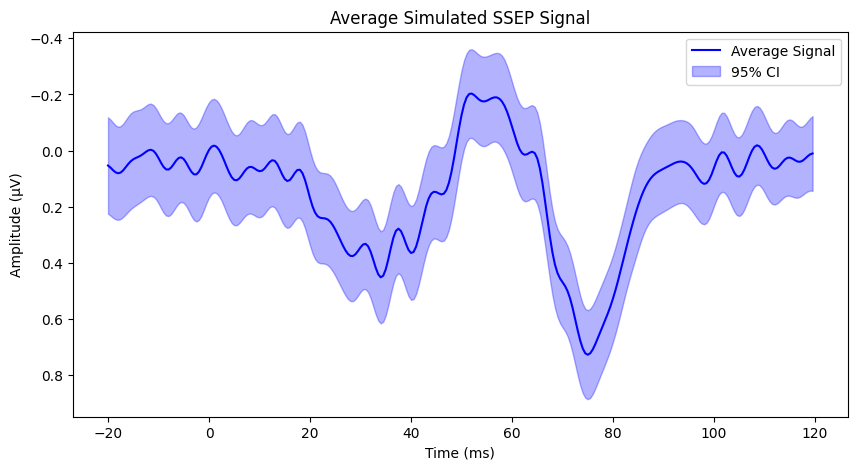

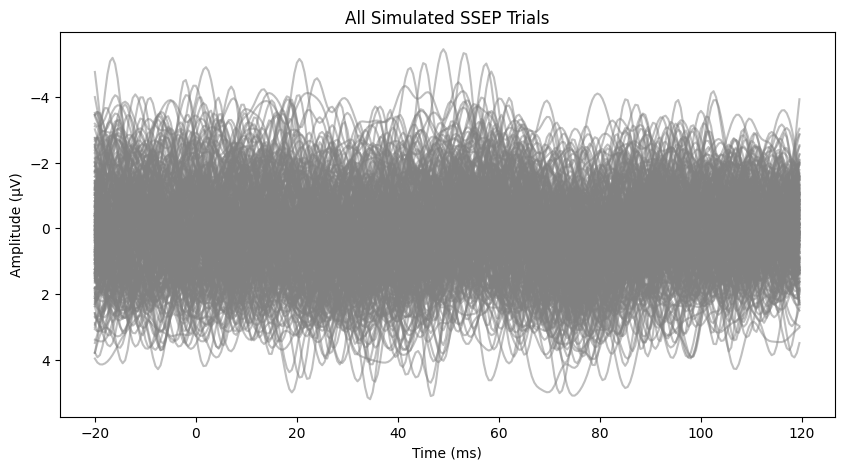

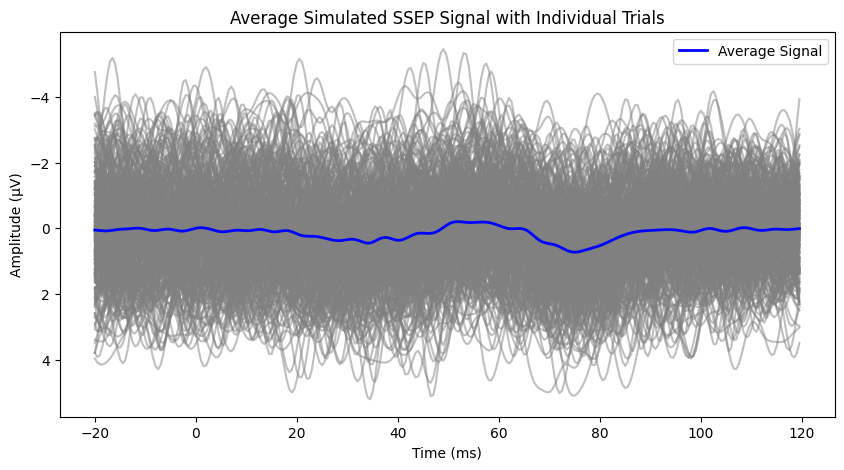

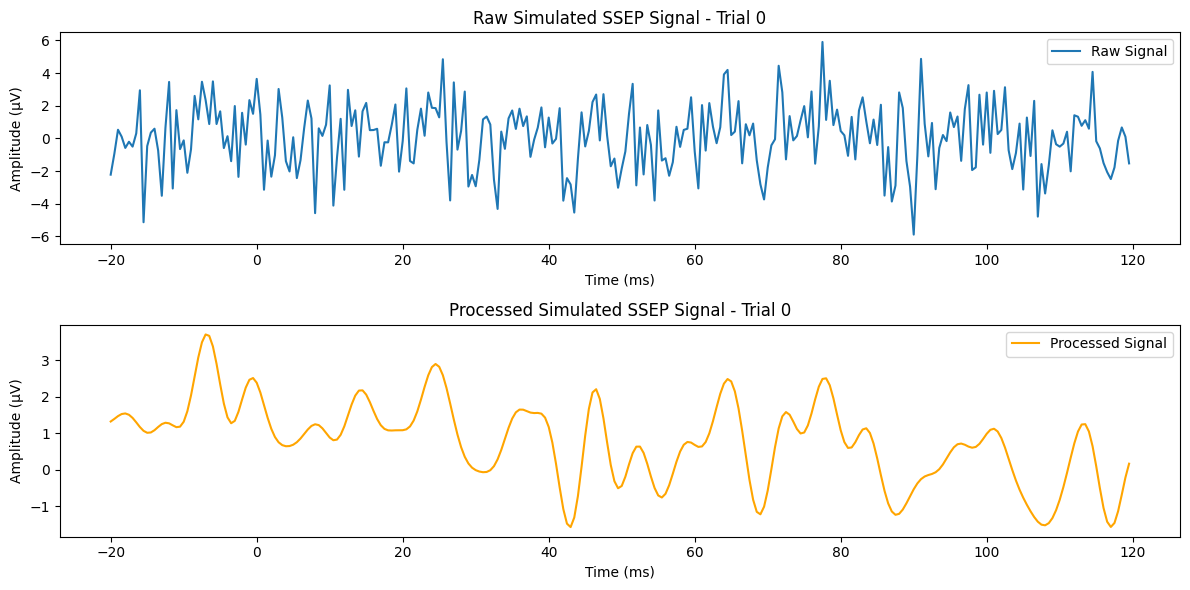

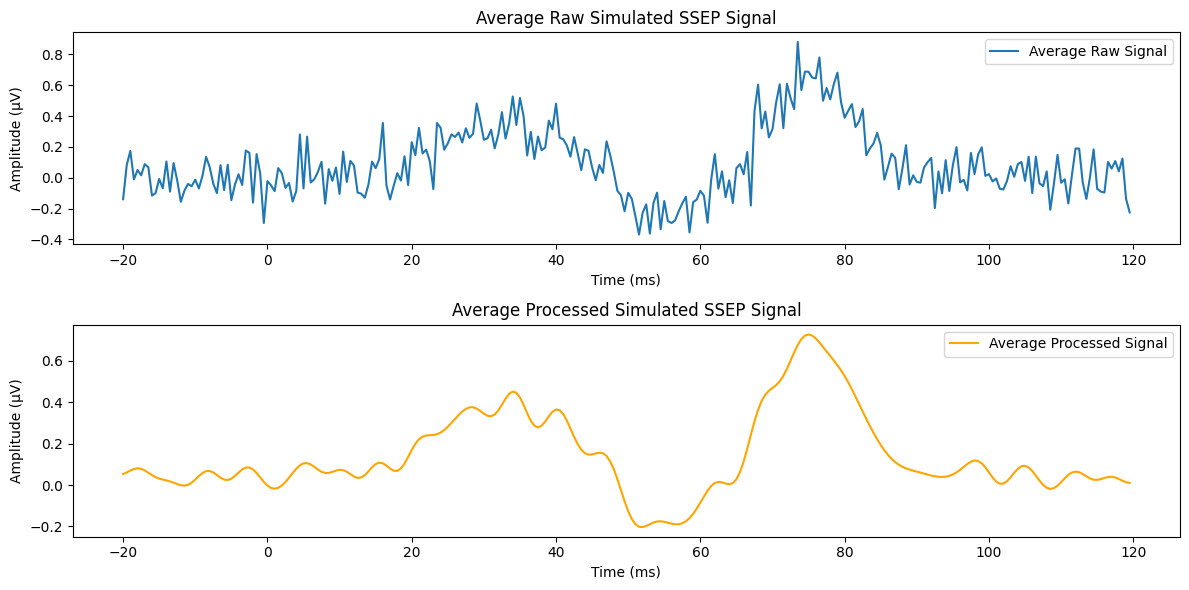

In [72]:
# here we test all of the stuff above


# sanity check for Dataset class
custom_peaks = [
    GaussianReboundPeak("P37", latency_ms=37.0, amp_uv=+.5, width_ms=10.0,
                        rebound_frac=.6, rebound_delay_ms=12, rebound_width_ms=12),
    Peak("P75", latency_ms=75.0, amp_uv=+.7, width_ms=6.0)
]
dataset = Dataset(peaks=custom_peaks, fs=2000, noise_rms_uv=2, rng_seed=42,pad_frac=2)
dataset.generate_trials(n_trials=300)

#print some info about the generated dataset
print(f"Generated {len(dataset.trials)} trials with {len(dataset.trials[0][0])} time points each.")
print(f"First trial time range: {dataset.trials[0][0][0]} ms to {dataset.trials[0][0][-1]} ms")
print(f"First trial signal snippet: {dataset.trials[0][1][:10]} ...")

# apply a simple preprocessing step to the dataset and check that it works without errors
preprocessor = Preprocessor(fs=dataset.fs)
preprocessor.add_lowpass(cutoff_hz=200.0, order=4)
preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
dataset.preprocess(preprocessor)

# testing plotting methods for the dataset
dataset.plot_average(show_ci=True)
dataset.plot_trials()
dataset.plot_average_with_trials()
dataset.plot_trial_comparison(trial_index=0)
dataset.plot_average_comparison()





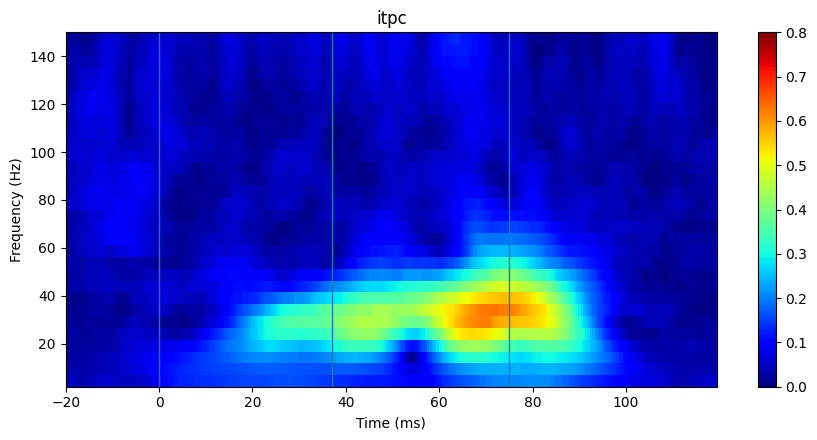

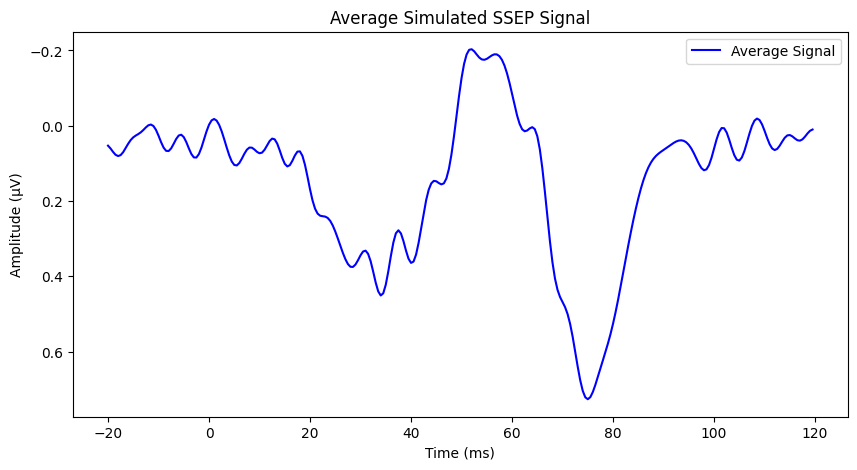

In [73]:
# here we test the decomposition and the plotting
# generating wavefam
# ---------------- example usage (original params) ----------------
srate = dataset.fs
wavtime = np.arange(-1, 1 + 1/srate, 1/srate)  # seconds, ±1s
n_frex = 30
frex = np.linspace(2, 150, n_frex)
fwhm = np.linspace(0.03, 0.01, n_frex)  # seconds
# set nData to the length of the simulated signals in dataset (after padding)
# get actual sizes from dataset
EEGpnts = len(dataset.trials[0][1])     # time points per trial
EEGtrials = len(dataset.trials)         # number of trials
# Cohen-style concatenated nData:
nData = EEGpnts * EEGtrials


wavefam = wavelet_family(frex=frex, fwhm=fwhm, srate=srate, wavtime=wavtime, n_data=nData).build()


# 1) compute complex TF once
dataset.compute_tf_complex_from_wavelet_family(wavefam, store=True,)

# 2) compute metrics anytime
m = dataset.tf_metrics(baseline_ms=(-20, 0), kind="db", store=True)

m["total_power_norm"]    # (freq, time)
m["induced_power_norm"]
m["evoked_power_norm"]
m["itpc"]


dataset.plot_tf_metric(
    metric="itpc",
    tlim_ms=(-20, 120),
    flim_hz=(2, 150),
    cmap="jet",
    vmin=0,
    vmax=.8,
    time_lines_ms=[0, 37, 75]
)

dataset.plot_average()




Here we test the `Dataset` class by creating a dataset with two peaks (P37 and P75), generating 300 trials, and applying a simple preprocessing pipeline that includes a low-pass filter followed by a band-pass filter. We then use the various plotting methods to visualize the average signal, individual trials, and comparisons between raw and processed signals. This allows us to confirm that the simulated peaks are present in the data and that the preprocessing steps are working as expected without introducing errors or artifacts.

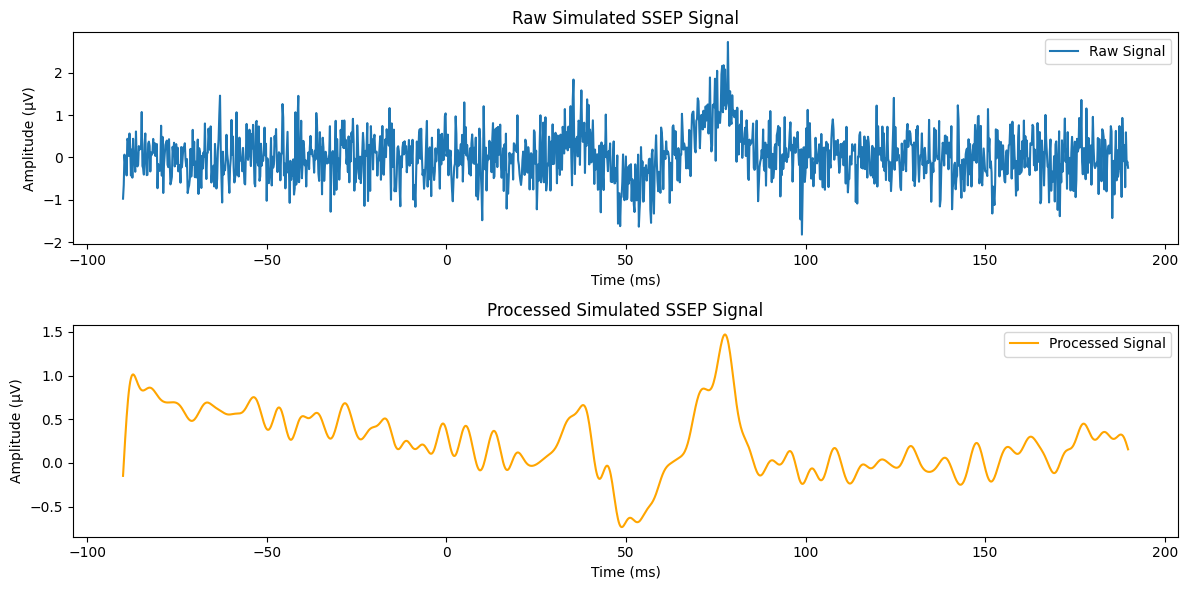

In [44]:
# Example usage
# Define some peaks for the simulation
custom_peaks = [
    GaussianReboundPeak("P37", latency_ms=37.0, amp_uv=+1.0, width_ms=5.0,
                        rebound_frac=.6, rebound_delay_ms=12, rebound_width_ms=12),
    Peak("P75", latency_ms=75.0, amp_uv=+1.2, width_ms=6.0)
]
# Create a dataset with the defined peaks
dataset = Dataset(peaks=custom_peaks, fs=5000, noise_rms_uv=0.5, rng_seed=42)
dataset.generate_trials(n_trials=10)
# Create a preprocessor and add some filters
preprocessor = Preprocessor(fs=dataset.fs)
preprocessor.add_lowpass(cutoff_hz=200.0, order=4)
preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
# Apply preprocessing to the first trial and visualize
import matplotlib.pyplot as plt
t_ms, raw_sig = dataset.trials[0]
processed_sig = preprocessor.apply(raw_sig)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_ms, raw_sig, label="Raw Signal")
plt.title("Raw Simulated SSEP Signal")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t_ms, processed_sig, label="Processed Signal", color="orange")
plt.title("Processed Simulated SSEP Signal")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.tight_layout()
plt.show()




This cell we will generate n subjects worth of simulated tibial SSEP data, each with a specified number of trials. We will then apply the same preprocessing pipeline to each subject's dataset and visualize the average signal across subjects to confirm that the simulated peaks are present and that the preprocessing steps are working as expected. This will allow us to create a larger synthetic dataset that can be used for testing and validating analysis pipelines, and to ensure that the simulated data behaves in a realistic manner across multiple subjects.

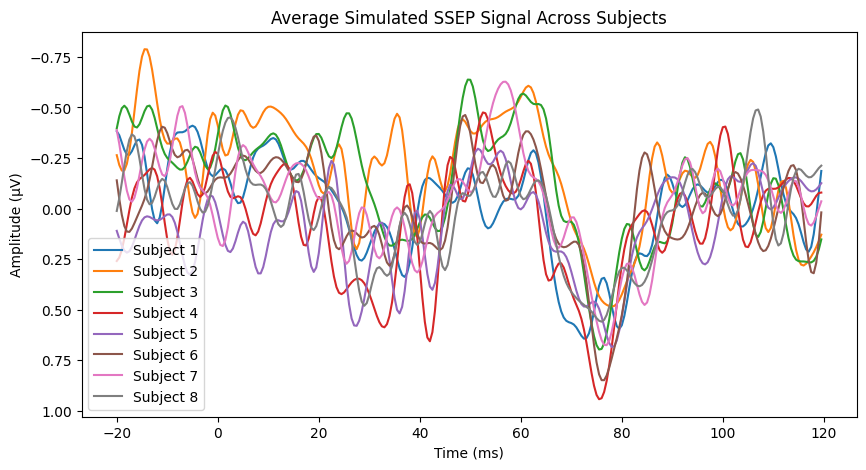

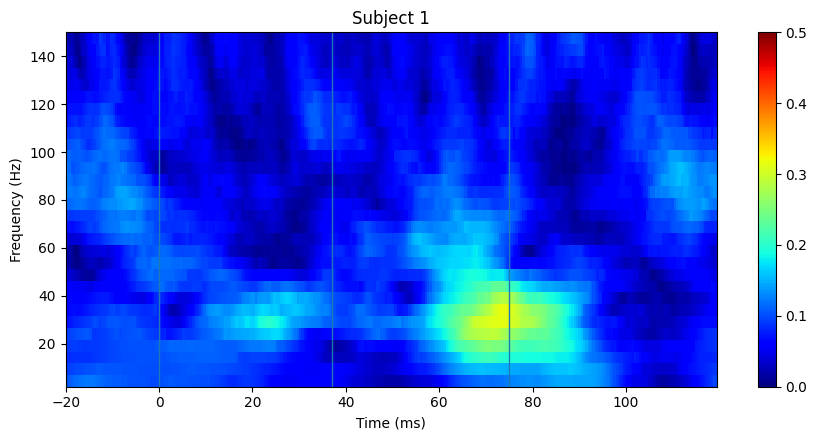

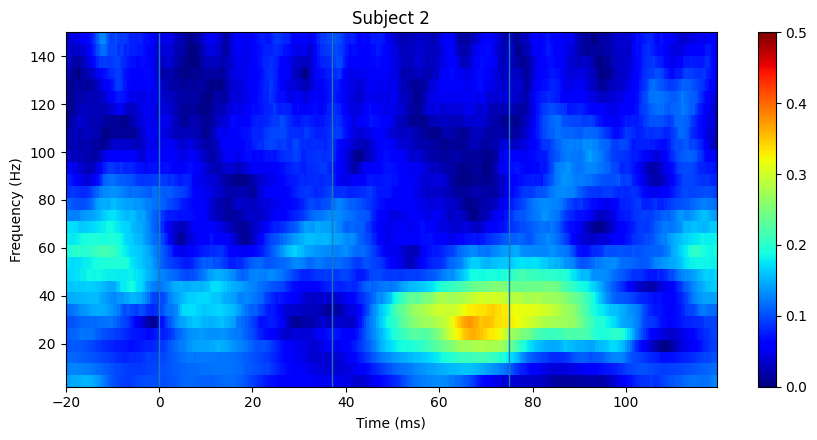

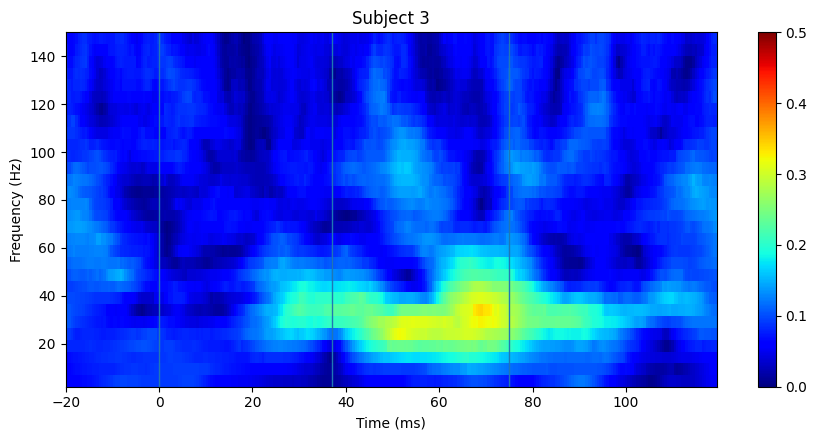

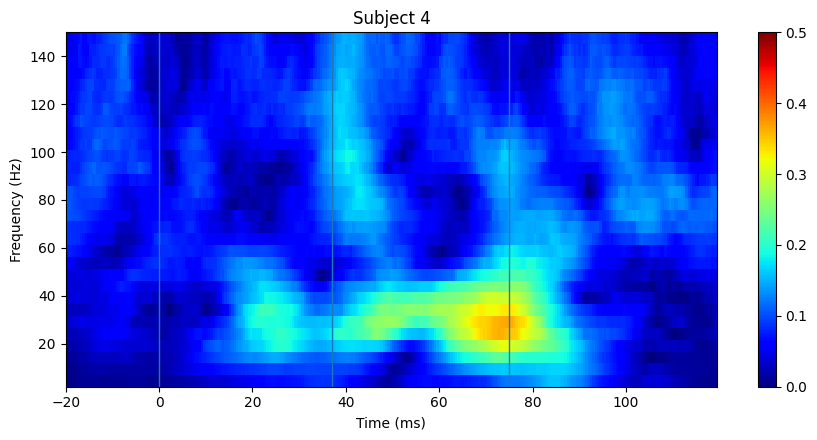

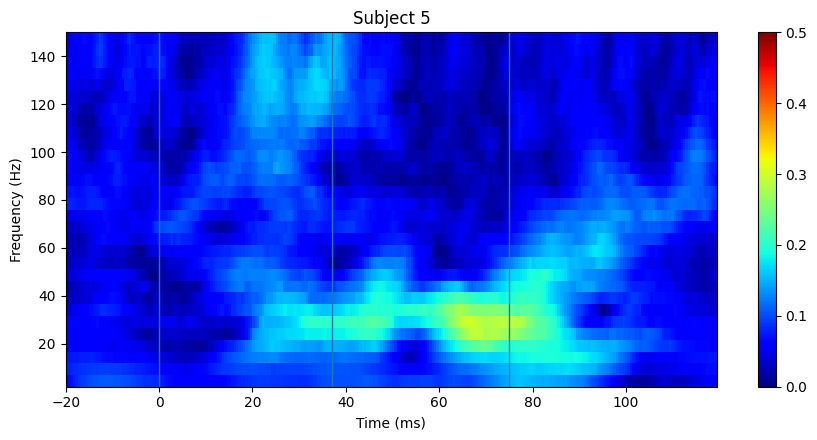

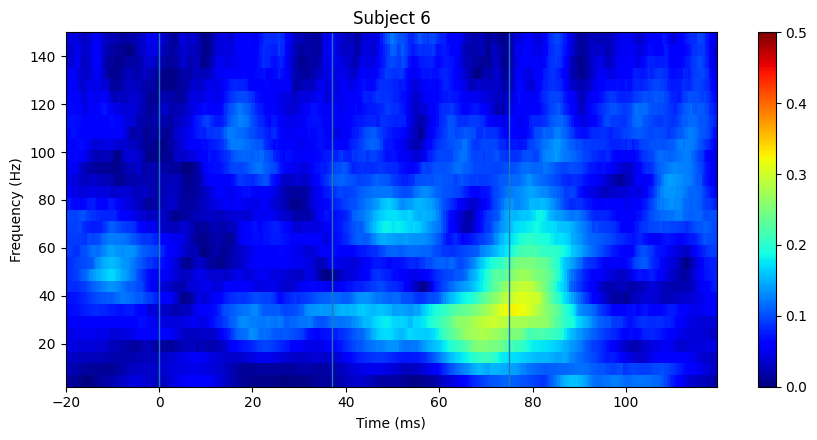

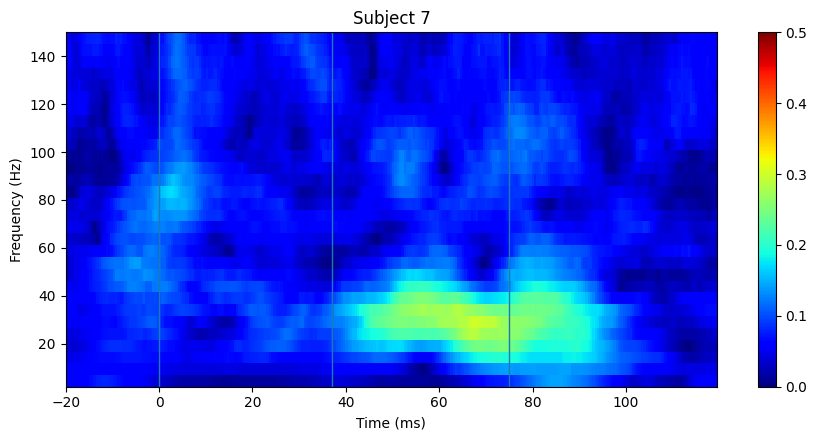

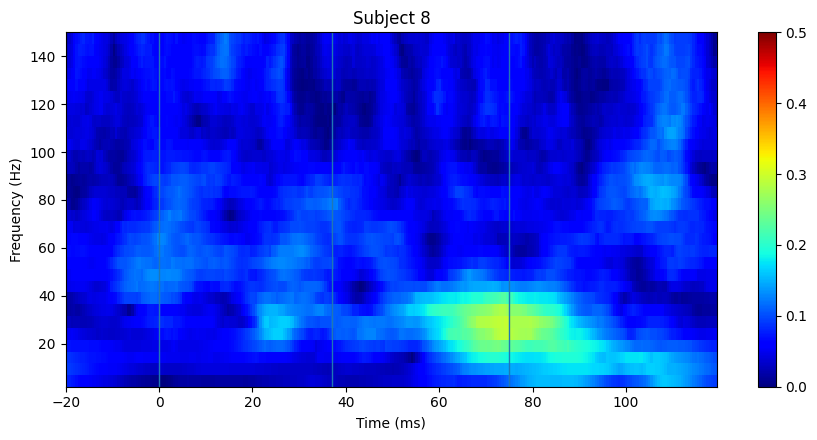

In [75]:
n=8  # number of subjects
subjects = []
for i in range(n):
    dataset = Dataset(peaks=custom_peaks, fs=2000, noise_rms_uv=5)
    dataset.generate_trials(n_trials=200)
    dataset.preprocess(preprocessor)
    dataset.compute_tf_complex_from_wavelet_family(wavefam, store=True,)
    dataset.tf_metrics(baseline_ms=(-20, 0), kind="db", store=True)
    subjects.append(dataset)

# Plot average signal across subjects
plt.figure(figsize=(10, 5))
for i, dataset in enumerate(subjects):
    t_ms, avg_sig = dataset.average()
    plt.plot(t_ms, avg_sig, label=f"Subject {i+1}")

plt.title("Average Simulated SSEP Signal Across Subjects")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

for i, dataset in enumerate(subjects):
    dataset.plot_tf_metric(
        metric="itpc",
        tlim_ms=(-20, 120),
        flim_hz=(2, 150),
        cmap="jet",
        vmin=0,
        vmax=.5,
        time_lines_ms=[0, 37, 75],
        title=f"Subject {i+1}"
    )

